# `mcsim` example use — VAR vs LP horse race

A lightweight version of the baseline study (chap_3): simulate a stable bivariate **VAR(4)** with recursive (Cholesky) identification, then score two estimator families against the true structural IRF (response of variable 1 to structural shock 1):

* **LP(4)** — local projections, identified by a first-stage VAR(4).
* **VAR(q) sweep** — reduced-form VAR of increasing order, Cholesky-identified.

It demonstrates the three contracts of the framework:

* **DGP** — a callable `(rng, T) -> data`.
* **Estimators** — callables `(data) -> irf_array`, built with `partial` so the whole sweep shares one interface.
* **Scoring** — done *after* `run`, against the closed-form true IRF.

To scale up to the full design, widen `VAR_ORDERS` to `range(1, P + H)` and raise `n_reps` / `horizon` — the `run` call is unchanged.

> **Note:** the DGP coefficient matrices below are a *placeholder* representative calibration, not yet the thesis's baseline numbers.

In [8]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt

from mcsim.dgp import VARSpec, scale_to_persistence, simulate_var, var_irf, spectral_radius
from mcsim.estimators import estimate_lp_irf, estimate_var_irf
from mcsim.simulation import MCConfig, run

## 1. Define the DGP

A bivariate VAR(4) with lower-triangular impact matrix `B`, rescaled so the companion spectral radius (persistence) equals `TARGET_RHO`. The adapter `var_dgp` matches the `(rng, T) -> data` contract.

In [9]:
P = 4 # 
TARGET_RHO = 0.9 # persistance 

A0 = np.array([ # coefficient array
    [[0.50, 0.10], [0.20, 0.45]],   # A_1
    [[0.00, 0.00], [0.00, 0.10]],   # A_2
    [[0.00, 0.00], [0.00, 0.00]],   # A_3
    [[0.10, 0.00], [0.00, 0.10]],   # A_4
])

B = np.array([[1.0, 0.0], [0.5, 1.0]])   # recursive (lower-triangular) impact matrix

DGP_SPEC = VARSpec(A=scale_to_persistence(A0, TARGET_RHO), B=B)
print("achieved spectral radius:", round(spectral_radius(DGP_SPEC.A), 4))

def var_dgp(rng, T, spec):
    return simulate_var(spec, T, rng)

dgp = partial(var_dgp, spec=DGP_SPEC)

achieved spectral radius: 0.9


## 1b. Visualize the DGP and the shock (no estimation)

Three pure views of the true model: a simulated realization of the two variables, the structural shocks $\varepsilon_t \sim N(0, I)$ that drove it, and the true impulse responses to a one-unit shock. Recursive identification is visible in the IRF panel: $y_1$'s impact response to $\varepsilon_2$ is exactly 0.

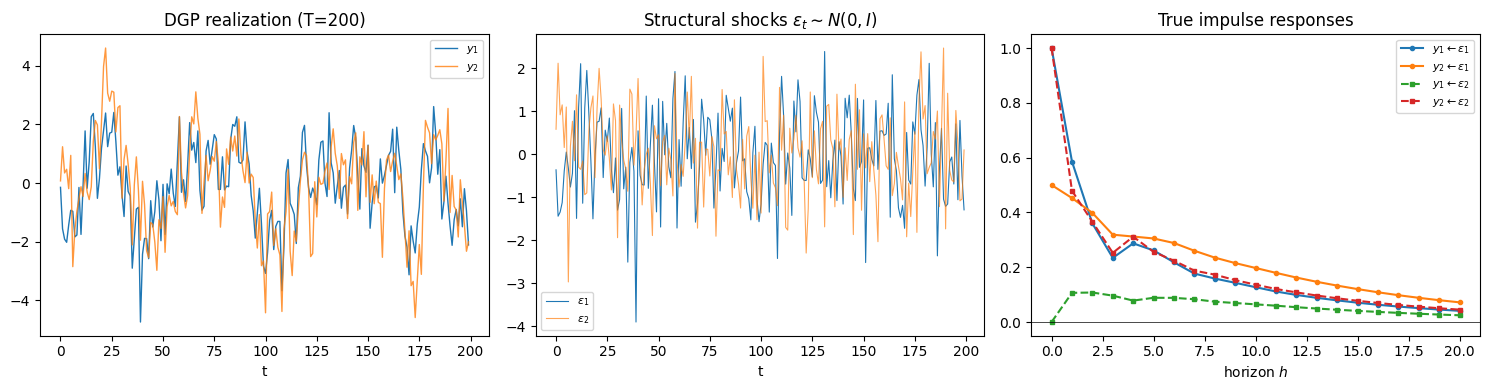

In [10]:
viz_rng = np.random.default_rng(0)
T_show, H_irf = 200, 20
Y_path, shocks = simulate_var(DGP_SPEC, T_show, viz_rng, return_shocks=True)

# True IRFs: response of each variable r to a unit shock m (no estimation).
irf = {(r, m): var_irf(DGP_SPEC, H_irf, shock=m, response=r) for r in range(2) for m in range(2)}
hh = np.arange(H_irf + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(Y_path[:, 0], lw=1, label="$y_1$")
axes[0].plot(Y_path[:, 1], lw=1, alpha=0.8, label="$y_2$")
axes[0].set_title(f"DGP realization (T={T_show})"); axes[0].set_xlabel("t"); axes[0].legend(fontsize=8)

axes[1].plot(shocks[:, 0], lw=0.8, label=r"$\varepsilon_1$")
axes[1].plot(shocks[:, 1], lw=0.8, alpha=0.7, label=r"$\varepsilon_2$")
axes[1].set_title(r"Structural shocks $\varepsilon_t \sim N(0, I)$"); axes[1].set_xlabel("t"); axes[1].legend(fontsize=8)

axes[2].plot(hh, irf[(0, 0)], marker="o", ms=3, label=r"$y_1 \leftarrow \varepsilon_1$")
axes[2].plot(hh, irf[(1, 0)], marker="o", ms=3, label=r"$y_2 \leftarrow \varepsilon_1$")
axes[2].plot(hh, irf[(0, 1)], marker="s", ms=3, ls="--", label=r"$y_1 \leftarrow \varepsilon_2$")
axes[2].plot(hh, irf[(1, 1)], marker="s", ms=3, ls="--", label=r"$y_2 \leftarrow \varepsilon_2$")
axes[2].axhline(0, color="k", lw=0.5)
axes[2].set_title("True impulse responses"); axes[2].set_xlabel("horizon $h$"); axes[2].legend(fontsize=8)

fig.tight_layout(); plt.show()

### 1c. The series as stacked, decaying shocks

The same idea made literal: $y_t = \sum_{j\ge 0} \Psi_j B\,\varepsilon_{t-j}$. Each faint line is one period's shock living out its impulse response (a decaying ripple starting at its arrival time); a few are highlighted to show the decay shape. The black line is their sum — the observed $y_1$. Each shock starts fresh at its arrival and decays; new shocks keep landing on top, so the series is the running total of all the still-decaying ripples. (Built from rest at $t=0$, so the sum is exact.)

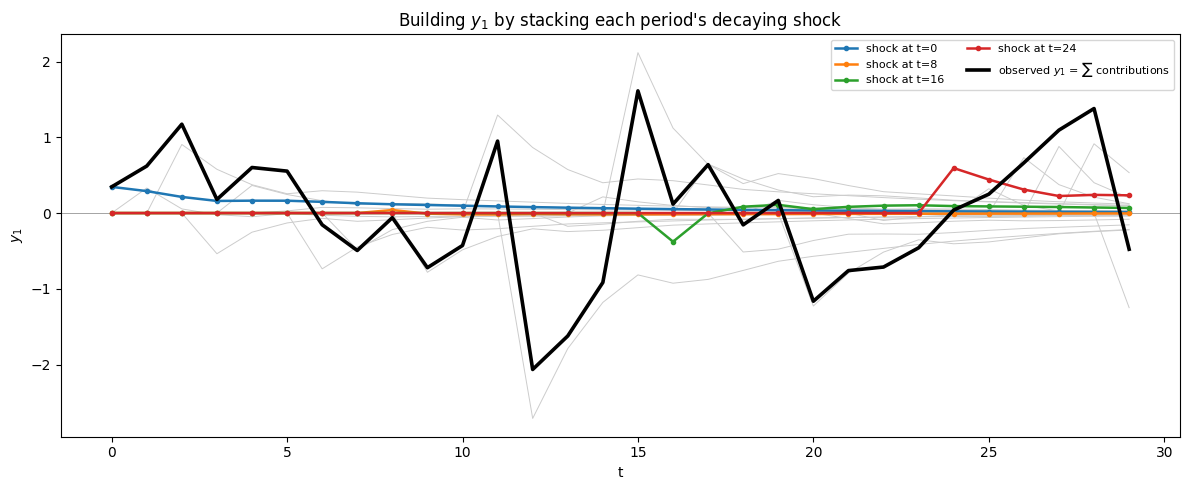

In [11]:
from mcsim.dgp import var_ma_matrices

bu_rng = np.random.default_rng(1)
T_bu = 30
eps_bu = bu_rng.standard_normal((T_bu, 2))   # structural shocks, starting from rest at t=0
Psi = var_ma_matrices(DGP_SPEC.A, T_bu)       # (T_bu+1, 2, 2)
Bmat = DGP_SPEC.B

# contribution of the period-s shock to y_1 at each time t >= s
contrib = np.zeros((T_bu, T_bu))              # contrib[s, t]
for s in range(T_bu):
    for t in range(s, T_bu):
        contrib[s, t] = (Psi[t - s] @ Bmat @ eps_bu[s])[0]

t_axis = np.arange(T_bu)
y1 = contrib.sum(axis=0)                      # observed y_1 = sum of every shock's decaying path
highlight = [0, 8, 16, 24]

fig, ax = plt.subplots(figsize=(12, 5))
for s in range(T_bu):                         # every shock's decaying contribution (faint)
    ax.plot(t_axis, contrib[s], color="0.8", lw=0.7, zorder=1)
for s in highlight:                           # a few highlighted so the decay shape is visible
    ax.plot(t_axis, contrib[s], lw=1.8, marker="o", ms=3, zorder=3, label=f"shock at t={s}")
ax.plot(t_axis, y1, "k-", lw=2.6, zorder=4, label=r"observed $y_1$ = $\sum$ contributions")
ax.axhline(0, color="gray", lw=0.5)
ax.set_title(r"Building $y_1$ by stacking each period's decaying shock")
ax.set_xlabel("t"); ax.set_ylabel("$y_1$")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout(); plt.show()

## 2. Configure the experiment

LP(4) plus a short VAR-order sweep, each bound to the `(data) -> irf` contract via `partial`. This is the same wiring the full baseline uses for its 24-estimator LP + VAR sweep.

In [12]:
horizon = 12
VAR_ORDERS = [x for x in range(1, 24)]

estimators = {"LP(4)": partial(estimate_lp_irf, p=P, horizon=horizon)}
estimators.update({f"VAR({q})": partial(estimate_var_irf, p=q, horizon=horizon) for q in VAR_ORDERS})

cfg = MCConfig(
    n_reps=1000,
    T=240,
    horizon=horizon,
    seed=20260527,
    n_jobs=-1,
    progress=True,
    estimators=estimators,
)
list(cfg.estimators)

['LP(4)',
 'VAR(1)',
 'VAR(2)',
 'VAR(3)',
 'VAR(4)',
 'VAR(5)',
 'VAR(6)',
 'VAR(7)',
 'VAR(8)',
 'VAR(9)',
 'VAR(10)',
 'VAR(11)',
 'VAR(12)',
 'VAR(13)',
 'VAR(14)',
 'VAR(15)',
 'VAR(16)',
 'VAR(17)',
 'VAR(18)',
 'VAR(19)',
 'VAR(20)',
 'VAR(21)',
 'VAR(22)',
 'VAR(23)']

## 3. Run the Monte Carlo

`run` returns the raw stacked IRF estimates, shape `(n_reps, horizon + 1)` per estimator, plus a per-estimator failure count.

In [13]:
results = run(dgp, cfg)

print({k: v.shape for k, v in results["irfs"].items()})
print("failures:", results["n_failures"])

MC reps: 100%|██████████| 1000/1000 [00:00<00:00, 1979.46it/s]


{'LP(4)': (1000, 13), 'VAR(1)': (1000, 13), 'VAR(2)': (1000, 13), 'VAR(3)': (1000, 13), 'VAR(4)': (1000, 13), 'VAR(5)': (1000, 13), 'VAR(6)': (1000, 13), 'VAR(7)': (1000, 13), 'VAR(8)': (1000, 13), 'VAR(9)': (1000, 13), 'VAR(10)': (1000, 13), 'VAR(11)': (1000, 13), 'VAR(12)': (1000, 13), 'VAR(13)': (1000, 13), 'VAR(14)': (1000, 13), 'VAR(15)': (1000, 13), 'VAR(16)': (1000, 13), 'VAR(17)': (1000, 13), 'VAR(18)': (1000, 13), 'VAR(19)': (1000, 13), 'VAR(20)': (1000, 13), 'VAR(21)': (1000, 13), 'VAR(22)': (1000, 13), 'VAR(23)': (1000, 13)}
failures: {'LP(4)': 0, 'VAR(1)': 0, 'VAR(2)': 0, 'VAR(3)': 0, 'VAR(4)': 0, 'VAR(5)': 0, 'VAR(6)': 0, 'VAR(7)': 0, 'VAR(8)': 0, 'VAR(9)': 0, 'VAR(10)': 0, 'VAR(11)': 0, 'VAR(12)': 0, 'VAR(13)': 0, 'VAR(14)': 0, 'VAR(15)': 0, 'VAR(16)': 0, 'VAR(17)': 0, 'VAR(18)': 0, 'VAR(19)': 0, 'VAR(20)': 0, 'VAR(21)': 0, 'VAR(22)': 0, 'VAR(23)': 0}


## 4. Score against the true IRF

The estimand has a closed form (`var_irf`). We compute bias and RMSE per horizon *after* the run, NaN-safe against any failed replications.

In [14]:
truth = var_irf(DGP_SPEC, horizon)  # var 1 <- shock 1, shape (horizon + 1,)

bias = {name: np.nanmean(stack - truth, axis=0) for name, stack in results["irfs"].items()}
rmse = {name: np.sqrt(np.nanmean((stack - truth) ** 2, axis=0)) for name, stack in results["irfs"].items()}

report = [0, 1, 2, 4, 8, 12]
print("RMSE of structural IRF (var1 <- shock1) by horizon")
print("estimator | " + " | ".join(f"h={h:<2d}" for h in report))
for name, r in rmse.items():
    print(f"{name:>9s} | " + " | ".join(f"{r[h]:.3f}" for h in report))

RMSE of structural IRF (var1 <- shock1) by horizon
estimator | h=0  | h=1  | h=2  | h=4  | h=8  | h=12
    LP(4) | 0.046 | 0.075 | 0.082 | 0.090 | 0.096 | 0.098
   VAR(1) | 0.048 | 0.073 | 0.090 | 0.103 | 0.097 | 0.075
   VAR(2) | 0.047 | 0.073 | 0.087 | 0.102 | 0.083 | 0.063
   VAR(3) | 0.047 | 0.074 | 0.081 | 0.092 | 0.073 | 0.056
   VAR(4) | 0.046 | 0.074 | 0.081 | 0.077 | 0.062 | 0.050
   VAR(5) | 0.046 | 0.075 | 0.082 | 0.087 | 0.065 | 0.053
   VAR(6) | 0.047 | 0.075 | 0.082 | 0.088 | 0.073 | 0.058
   VAR(7) | 0.047 | 0.076 | 0.083 | 0.089 | 0.079 | 0.061
   VAR(8) | 0.047 | 0.077 | 0.083 | 0.089 | 0.084 | 0.065
   VAR(9) | 0.048 | 0.077 | 0.083 | 0.090 | 0.094 | 0.067
  VAR(10) | 0.048 | 0.078 | 0.084 | 0.091 | 0.095 | 0.074
  VAR(11) | 0.049 | 0.079 | 0.085 | 0.092 | 0.096 | 0.081
  VAR(12) | 0.049 | 0.079 | 0.085 | 0.093 | 0.096 | 0.087
  VAR(13) | 0.049 | 0.080 | 0.087 | 0.093 | 0.097 | 0.095
  VAR(14) | 0.049 | 0.081 | 0.087 | 0.095 | 0.098 | 0.097
  VAR(15) | 0.050 | 0.082 |

## 5. Plots

Left: the true IRF against the mean estimated IRF of each estimator. Right: RMSE across the horizon — LP(4) as the reference line against the VAR sweep, the complexity-adjusted comparison.

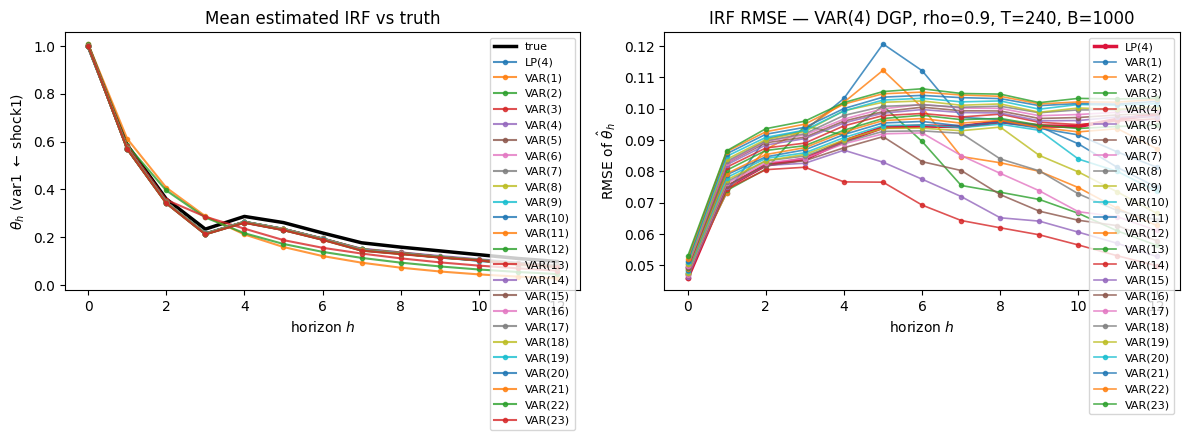

In [15]:
h = np.arange(horizon + 1)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))

ax0.plot(h, truth, "k-", lw=2.5, label="true")
for name, stack in results["irfs"].items():
    ax0.plot(h, np.nanmean(stack, axis=0), marker="o", ms=3, alpha=0.8, label=name)
ax0.set_title("Mean estimated IRF vs truth")
ax0.set_xlabel("horizon $h$"); ax0.set_ylabel(r"$\theta_h$ (var1 $\leftarrow$ shock1)")
ax0.legend(fontsize=8)

for name, r in rmse.items():
    style = dict(lw=2.5, color="crimson") if name == "LP(4)" else dict(lw=1.2, alpha=0.8)
    ax1.plot(h, r, marker="o", ms=3, label=name, **style)
ax1.set_title(f"IRF RMSE — VAR(4) DGP, rho={TARGET_RHO}, T={cfg.T}, B={cfg.n_reps}")
ax1.set_xlabel("horizon $h$"); ax1.set_ylabel(r"RMSE of $\hat{\theta}_h$")
ax1.legend(fontsize=8)

fig.tight_layout()
plt.show()